# Raster Data

Raster data represents geographic information as a grid of cells (pixels), where each cell stores a value such as elevation, temperature, or reflectance. This module introduces the tools and techniques for reading, exploring, and manipulating raster data in Python using `xarray` and `rioxarray`.

**Topics covered in this module:**
- Creating simple raster layers with NumPy
- xarray data structures: Dataset and DataArray
- Reading and exploring raster files
- Selecting data by index, coordinates, and conditions
- Clipping and masking rasters with vector boundaries
- Merging raster tiles into mosaics
- Converting between raster and vector formats (vectorize/rasterize)
- Resampling raster data to different resolutions

## Learning Objectives

At the end of this module, you should be able to:
- Explain the difference between xarray Dataset and DataArray objects
- Import and visualize single-band raster data using xarray and rioxarray
- Select raster data by index (`.isel()`), coordinates (`.sel()`), and logical conditions (`.where()`)
- Clip and mask rasters using vector boundary datasets
- Merge multiple raster tiles into a mosaic
- Convert between raster and vector formats (vectorize and rasterize)
- Resample raster data to different spatial resolutions (upscale and downscale)

## Exploring raster data in Python 

Raster data consists of rows and columns of cells or pixels, with each cell representing a single value. This type of data is often thought of as images, although raster datasets can be stored in various formats such as **ASCII text files** or **Binary Large Objects (BLOBs)** within databases.

![Raster Data Representation](img/raster_rep.png)

*Image Source: [ESRI - What is Raster Data](https://desktop.arcgis.com/en/arcmap/latest/manage-data/raster-and-images/what-is-raster-data.htm)*

Raster data represents the world as a grid of equally sized cells or pixels, where each cell has a value representing information, such as temperature, elevation, or land cover. There are various reasons why you might want to store your data in raster format:

- It is a simple data structure: A matrix of cells with values representing information about the observed surface/phenomena
- It is an efficient way to store data from large continuous surfaces
- It is a powerful format that can be used for various spatial and statistical analysis
- You can perform fast overlays with multiple layers 

There are two primary ways of working with raster data:
- Single-band raster: Each pixel has one value (e.g., elevation or temperature).
- Multiband raster: Each pixel has multiple values (e.g., Red, Green, and Blue bands in satellite imagery).

A key characteristic of any raster data is its **Resolution**. Resolution refers to the ground distance that each cell represents. For example, if the resolution is two meters, each cell corresponds to an area two meters by two meters. A raster dataset with higher resolution can show more detail, but it will also have larger file sizes.

Raster data can be stored in a variety of **formats**, some of the more common ones include:

- **TIFF (Tagged Image File Format)**: This is the most common geospatial raster format due to its flexibility. It allows for storage of multiple bands, metadata, and internal compression. However, TIFF files can sometimes be incompatible across software.
- **JPEG, GIF, BMP, PNG**: These formats are more suitable for images used in presentations or online applications. While common, they are not as robust for storing geospatial data due to lack of metadata support.
- **ASCII Grid**: This format is often used for storing elevation data as simple text files, with spatial information stored in a header.

## Creating a simple raster layer using numpy

To get a better sense of how the raster data looks like, we can start by creating a simple two-dimensional array in Python using numpy. In the following, we will modify the raster layer to represent a simple terrain that has a hill in the middle of the grid. We do this by setting higher values in the center while the other values are represented with value 0.

Creating a simple 2D raster layer (or 2D array) with 10x10 array can be done using a numpy method `.zeros()` which fills the cells (pixels) with zeros. Each zero represents a default pixel value (e.g. 0 elevation). You can think of this as an empty raster grid:

In [1]:
import numpy as np
import matplotlib.pyplot as plt

raster_layer = np.zeros((10, 10))
raster_layer

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

Next, we modify the raster layer to represent a simple terrain and add larger numbers in the middle of the grid by setting higher values in the center. We can do this by `slicing` the numpy array using the indices of the array and updating the numbers on those locations to be higher. Slicing numpy arrays happens in a similar manner to working with Python lists and accessing the items of a list. However, we do this in two dimensions by accessing the values stored in specific rows and columns by following the syntax: `[start-row-idx: end-row-idx, start-col-idx: end-col-idx]`. Thus, we can update the values in our 2D array as follows:

In [2]:
raster_layer[4:7, 4:7] = 5
raster_layer[5, 5] = 10
raster_layer

array([[ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  5.,  5.,  5.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  5., 10.,  5.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  5.,  5.,  5.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.]])

Here we first updated the cells between the fourth and seventh rows and columns ([4:7, 4:7]) to have a value 5, and then we updated the center of the matrix to represent the peak of the hill having a value 10. As a result, we have a simple raster layer that simulates a simple terrain. We can also plot this raster layer, using matplotlib library and its `.imshow()` function:

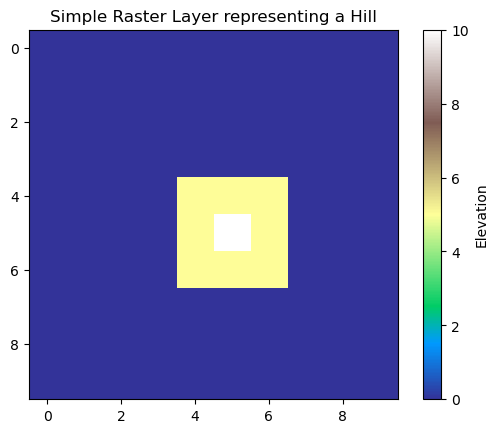

In [3]:
plt.imshow(raster_layer, cmap='terrain')
plt.colorbar(label='Elevation')
plt.title('Simple Raster Layer representing a Hill')
plt.show()

***Figure.** A simple raster layer representing elevation.*

As a result, we have a simple map that represents the elevation of the hill with different colors. The **colormap** (a color mapping scheme that assigns colors to data values) of the visualization was determined using the parameter `cmap`, while the `plt.colorbar()` function was used to add a legend to the right side of the image, and the `plt.title()` was used to add a simple title for the image.

This demonstrates a toy example how we can produce a simple raster layer from scratch. However, there are various aspects related to working with GIS raster data, such as specifying the metadata for this layer. Basically, the data we have here is simply a two-dimensional array (matrix) that does not tell anything about the *spatial resolution* of the data, nor in which area of the world this data is located (i.e. coordinates) or the *coordinate reference system* this data is represented in. In the next section, we start working with real raster data and cover more aspects that relate to spatial raster data.

## Data structures in xarray

Now that you have learned some basics about raster data and how to create a simple 2-dimensional raster array using numpy, we continue to explore in a more comprehensive manner how to work with real-world raster data using `xarray` and `rioxarray` libraries. The xarray library is a highly useful tool for storing, representing and manipulating raster data, while rioxarray provides various raster processing (GIS) capabilities on top of the xarray data structures, such as reading and writing several different raster formats and conducting different geocomputational tasks. Under the hood, rioxarray uses another Python library called `rasterio` (which works with N-dimensional numpy arrays) but the benefit of xarray and rioxarray is that they provide easier and more intuitive way to work with raster data layers, in a bit similar manner as working with vector data using geopandas.

- [`xarray`](https://docs.xarray.dev/en/stable/): A powerful library for working with labeled, multi-dimensional arrays in Python. It is particularly useful for handling scientific data, including time series and spatial data.
- [`rioxarray`](https://corteva.github.io/rioxarray/stable/): An extension of xarray designed for geospatial raster data operations. It builds on top of [`rasterio`](https://rasterio.readthedocs.io/en/latest/) to handle reading and writing raster formats like GeoTIFF, working with CRS, and performing GIS-specific tasks like reprojection. This combination allows for easy manipulation of spatial data in a highly efficient manner.

When working with raster data, you typically have various layers that represent different geographical features of the world (e.g. elevation, temperature, precipitation etc.) and this data is possibly captured at different times, meaning that you may have longitudinal (repetitive) observations from the same area, constituting time series data. You often need to combine information from these layers to conduct meaningful analysis. One of the greatest benefits of xarray is that you can easily store, combine, and analyze all different layers via a single object.

## Dataset and DataArray 

The two fundamental data structures provided by xarray are `DataArray` and `Dataset`. Both of them build upon and extend the strengths of numpy and pandas libraries. 
- The `DataArray` is a labeled N-dimensional array that is similar to pandas.Series but works with raster data (stored as numpy arrays). 
- The `Dataset` is a multi-dimensional in-memory array database that contains multiple DataArray objects. In addition to the variables containing the observations of a given phenomena, you also have the `x` and `y` coordinates of the observations stored in separate layers, as well as metadata providing relevant information about your data, such as Coordinate Reference System and/or time. Thus, a Dataset containing raster data is very similar to geopandas.GeoDataFrame.

<img src="img/xarray-dataset-diagram.png" width="600">

Some of the benefits of xarray include:
- A more intuitive and user-friendly interface to work with multidimensional arrays (compared to numpy)
- The possibility to select and combine data along a dimension across all arrays in a Dataset simultaneously
- Compatibility with a large ecosystem of Python libraries that work with arrays / raster data
- Tight integration of functionalities from well-known Python data analysis libraries, such as pandas, numpy, matplotlib, and dask

In the following, we will introduce some of the basic functionalities of xarray data structures.

## Reading a file into Dataset

We start by investigating a simple elevation dataset using xarray that represents a Digital Elevation Model (DEM) of the Keweenaw Peninsula. To read a raster data file (such as GeoTIFF) into xarray, we can use the  `.open_dataset()` function.

In [4]:
import xarray as xr
data = xr.open_dataset('data/n47_w089_1arc_v3.tif', engine="rasterio")
data

<xarray.Dataset> Size: 52MB
Dimensions:      (band: 1, x: 3601, y: 3601)
Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 29kB -89.0 -89.0 -89.0 -89.0 ... -88.0 -88.0 -88.0
  * y            (y) float64 29kB 48.0 48.0 48.0 48.0 ... 47.0 47.0 47.0 47.0
    spatial_ref  int64 8B ...
Data variables:
    band_data    (band, y, x) float32 52MB ...

In [5]:
type(data)

xarray.core.dataset.Dataset

Now we have read the GeoTIFF file into an `xarray.Dataset` into a variable `data`. The Dataset contains the actual data values for the raster cells, as well as other relevant attribute information related to the data:

- `Dimensions` show the number of bands (in this case, 1), and number of cells (3612) on the x and y axis
- `Coordinates` is a container with the actual x and y coordinates of the cells, the CRS information stored in the `spatial_ref` attribute, and the band attribute that shows the number of bands.
- `Data variables` contains the actual data values of the cells (e.g. elevations)

Because the Dataset only consists of a single band (i.e. the elevation values), it might make sense to reduce the dimensions of our dataset by dropping the band attribute because it is not really providing any useful information. We can subset the data and remove a specific dimension using the `.squeeze()` method. In the following, we drop the "band" dimension:

In [6]:
data = data.squeeze("band", drop=True)
data

<xarray.Dataset> Size: 52MB
Dimensions:      (x: 3601, y: 3601)
Coordinates:
  * x            (x) float64 29kB -89.0 -89.0 -89.0 -89.0 ... -88.0 -88.0 -88.0
  * y            (y) float64 29kB 48.0 48.0 48.0 48.0 ... 47.0 47.0 47.0 47.0
    spatial_ref  int64 8B ...
Data variables:
    band_data    (y, x) float32 52MB ...

As a result, now the Dimensions and Coordinates only shows the data for x and y axis.

## Renaming data variables

To make the data more intuitive to use, we can also change the name of the data variable from `band_data` into `elevation`. We can change the name of an attribute by using the `.rename()` method which takes a dictionary with syntax `{"old_name": "new_name"}`:

In [7]:
data = data.rename({"band_data": "elevation"})
data

<xarray.Dataset> Size: 52MB
Dimensions:      (x: 3601, y: 3601)
Coordinates:
  * x            (x) float64 29kB -89.0 -89.0 -89.0 -89.0 ... -88.0 -88.0 -88.0
  * y            (y) float64 29kB 48.0 48.0 48.0 48.0 ... 47.0 47.0 47.0 47.0
    spatial_ref  int64 8B ...
Data variables:
    elevation    (y, x) float32 52MB ...

Now the name of the data variable has been changed to `elevation` which makes it more intuitive and convenient to use than a generic name.

## Extracting basic information about the raster dataset

One of the typical things that you want to do when exploring a new dataset is to calculate some basic summary statistics, like finding the minimum, maximum, mean, and standard deviation. To extract this information, xarray provides similar functionalities as pandas to compute some basic statistics out of your data. For instance, we can extract the maximum elevation by calling the `.max()` method:

In [8]:
data["elevation"].max()

<xarray.DataArray 'elevation' ()> Size: 4B
array(470., dtype=float32)
Coordinates:
    spatial_ref  int64 8B ...
Attributes: (12/24)
    AREA_OR_POINT:                Point
    DTED_CompilationDate:         2
    DTED_DataEdition:             1
    DTED_DigitizingSystem:        SRTM      
    DTED_HorizontalAccuracy:      13
    DTED_HorizontalDatum:         WGS84
    ...                           ...
    DTED_UniqueRef_DSI:           F18 117        
    DTED_UniqueRef_UHL:           F18 117     
    DTED_VerticalAccuracy_ACC:    4
    DTED_VerticalAccuracy_UHL:    4
    DTED_VerticalDatum:           E96
    units:                        m

That produces quite a lot of information as it happens that xarray returns by default an `DataArray`. However, when we explore the output, we can see that the single value in the array is `470` which is the highest point in our data. However, it would be more useful to get the actual single number. We can extract the actual numerical value from the data by adding `.item()` after the command. The `.item()` method returns the xarray.Dataset element as a regular Python scalar value which is similar to what e.g. pandas returns when you call the .max() or .min(), as shown below: 

In [9]:
data["elevation"].max().item()

470.0

In [10]:
data["elevation"].min().item()

175.0

#### Quiz

When we read the DEM file, `xr.open_dataset()` returned a `Dataset`. But `data["elevation"]` is a `DataArray`. What is the relationship between these two? Why did we need `.item()` when calling `data["elevation"].max()`?

In [ ]:
# Use this cell to enter your solution.


We can further read the shape, width, height, resolution, and bounds attributes of the Dataset, as follows.

In [11]:
# Dimensions
print(data.rio.shape)
print(data.rio.width)
print(data.rio.height)

(3601, 3601)
3601
3601


In [12]:
# Resolution
data.rio.resolution() # unit is in degrees, same as the data crs

(0.0002777777777777778, -0.0002777777777777778)

In [13]:
# Bounds of the file
data.rio.bounds() # unit is in degrees, same as the data crs

(-89.00013888888888, 46.9998611111111, -87.99986111111112, 48.000138888888884)

## Creating a new data variable

At the moment, we only have one data variable in our Dataset, i.e. the elevation. However, it is easy create new data variables into your Dataset e.g. based on specific calculations or data conversions. For instance, we might be interested to calculate the relative height (i.e. relief) which tells how much higher the elevations are relative to the lowest elevation in the area. This can be calculated by subtracting the lowest elevation from the elevation in an area. In the following, we create a new data variable called `"relative_height"` into our Dataset based on a simple mathematical calculation. You can create new data variables into your Dataset by using square brackets and the name of your variable as a string (e.g. `data["THE_NAME"]`), as follows:

In [14]:
min_elevation = data["elevation"].min().item()

# Calculate the relief
data["relative_height"] = data["elevation"] - min_elevation
data

<xarray.Dataset> Size: 104MB
Dimensions:          (x: 3601, y: 3601)
Coordinates:
  * x                (x) float64 29kB -89.0 -89.0 -89.0 ... -88.0 -88.0 -88.0
  * y                (y) float64 29kB 48.0 48.0 48.0 48.0 ... 47.0 47.0 47.0
    spatial_ref      int64 8B ...
Data variables:
    elevation        (y, x) float32 52MB 179.0 179.0 179.0 ... 179.0 179.0 179.0
    relative_height  (y, x) float32 52MB 4.0 4.0 4.0 4.0 4.0 ... 4.0 4.0 4.0 4.0

As a result, we can see that a new data variable called `"relative_height"` was created and stored into our Dataset. All of the data variables stored in a Dataset are of type DataArray. We can confirm the data type by typing: 

In [15]:
type(data["elevation"])

xarray.core.dataarray.DataArray

Ultimately, you can store as many data variables to your dataset as you like. In case you are interested to explore all the data variables that are presented in your Dataset, you can do this by calling `.data_vars` attribute as follows: 

In [16]:
data.data_vars

Data variables:
    elevation        (y, x) float32 52MB 179.0 179.0 179.0 ... 179.0 179.0 179.0
    relative_height  (y, x) float32 52MB 4.0 4.0 4.0 4.0 4.0 ... 4.0 4.0 4.0 4.0

Here, we can see the names of the data variables, as well as some basic information about the data itself including the data type, size of the data in MiB, and a snippet of the actual values in the DataArrays. In case you are only interested to find out the names of the data variables, you can extract them as a list as follows:

In [17]:
list(data.data_vars)

['elevation', 'relative_height']

## Plotting a data variable

Thus far we have explored some of the basic characteristics of the xarray data structures. However, we have not yet plotted anything on a map, which is also one of the typical things that you want to do whenever working with new data. The xarray library provides very similar plotting functionality as geopandas, i.e. you can easily create a visualization out of your DataArray objects by using the `.plot()` method that uses matplotlib library in the background. In the following, we create a simple map out of the `"relative_height"` data variable: 

Text(0.5, 1.0, 'Elevation')

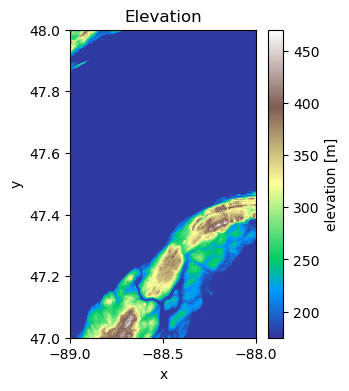

In [18]:
data["elevation"].plot(cmap="terrain",figsize=(3,4))
plt.title("Elevation")

Great! Now we have a nice simple map that shows the relative height of the landscape which transitions from the highest point (Sylvania Wilderness) at the Wisconsin border to the south shore of Lake Superior. Notice that we used the "terrain" colormap.

## Common raster operations

In the following sections, we will cover several common operations for working with raster data: selecting subsets, clipping to boundaries, masking, merging tiles, converting formats, and resampling to different resolutions.

When working with raster data, there are various operations and techniques that might be useful when preprocessing the data for further analysis. Some typical raster operations include **selecting**, **clipping** or **masking** raster to include only pixels that are located in a given area or at given indices, merging multiple raster tiles into a single raster **mosaic**, **converting** raster data into vector format (and vice versa), or **resampling** the raster pixels into higher or lower spatial resolution (upscaling, downscaling). We will learn how to conduct these kind of raster operations using `xarray`, `rioxarray`, `geocube` and `rasterio` Python libraries.

## Selecting data

Being able to select data based on indices or certain criteria (e.g. all values above specific threshold) is one of the most common operations that you need to do when working with any kind of data (raster, vector, as well as non-geographical data). When working with raster data, we can take advantage of xarray's flexible indexing routines that combine the best features of numpy and pandas for data selection.

There are various ways how you can select data from DataArray and Dataset, but some of the most commonly used methods include `.isel()`, `.sel()` and `.where()`.

### Selecting data by index values

The logic for selecting data from a DataArray values works quite similarly as we have learned using pandas (for Series and DataFrame objects), except that the returned object in xarray is always another DataArray. To select data based on specific index values, we can take advantage of the `.isel()` method that can be used similarly with Dataset and DataArray objects. 

For instance, we might be interested to select a cell at index `[0, 0]` in the array which corresponds to the cell that is located at the very top-left corner of the raster. To do this, we specify that the index value for both `x` and `y` dimension is `0` when calling the `.isel()` method:

In [19]:
selected_cell = data.isel(x=0, y=0)
selected_cell

<xarray.Dataset> Size: 32B
Dimensions:          ()
Coordinates:
    x                float64 8B -89.0
    y                float64 8B 48.0
    spatial_ref      int64 8B ...
Data variables:
    elevation        float32 4B 179.0
    relative_height  float32 4B 4.0

As we can see, the output is always returned as an xarray object, which in our case is a `Dataset`. To access the `elevation` or `relative_height` value at this given position, we can use the `.item()` which will return the value as a regular number:

In [20]:
selected_cell["elevation"].item()

179.0

In [21]:
selected_cell["relative_height"].item()

4.0

Quite often when working with raster data, you are interested to select a range of values from a given raster (called **slicing**). To slice the data based on index ranges, we can use the same `.isel()` method and provide the information about the index range using the Python's built-in `slice()` function that can be used to specify a range of indices to be included in the selection by specifying `start` and `end` index positions. In the following, we will select the first 1000 cells in the x and y dimensions:

In [22]:
selection = data.isel(x=slice(0, 1000), y=slice(0, 1000))
selection

<xarray.Dataset> Size: 8MB
Dimensions:          (x: 1000, y: 1000)
Coordinates:
  * x                (x) float64 8kB -89.0 -89.0 -89.0 ... -88.72 -88.72 -88.72
  * y                (y) float64 8kB 48.0 48.0 48.0 48.0 ... 47.72 47.72 47.72
    spatial_ref      int64 8B ...
Data variables:
    elevation        (y, x) float32 4MB 179.0 179.0 179.0 ... 179.0 179.0 179.0
    relative_height  (y, x) float32 4MB 4.0 4.0 4.0 4.0 4.0 ... 4.0 4.0 4.0 4.0

Text(0.5, 1.0, 'Elevation for the selected cells')

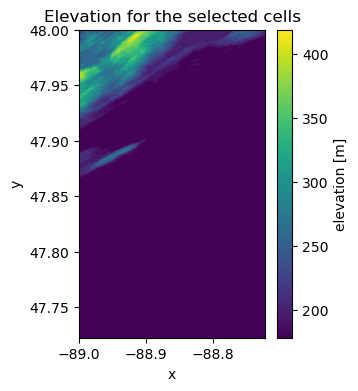

In [23]:
selection["elevation"].plot(figsize=(3,4))
plt.title("Elevation for the selected cells")

As we can see, now the shape of our output Dataset is 1000x1000 cells and the selection covers to top-left corner of our input Dataset. 

### Selecting data based on coordinates

While selecting data based on index positions might be useful in certain situations, quite often you want to select data based on coordinates. To do this, we can take advantage of the coordinate labels using `.sel()` method, which allows for more intuitive selection by providing the actual coordinates for you area of interest. Next, we will do the selection for given lat/lon ranges:

In [24]:
area_of_interest = data.sel(x=slice(-88.8, -88.4), y=slice(47.4,47))

Note that the slicing on y is slice(47.4, 47), not slice(47, 47.4)! This is because xarray slicing follows the ordering of the coordinate values. If your latitude coordinate is sorted in descending order (from a higher to a lower value), then slicing from a higher limit to a lower limit is natural and works as expected. In other words, the slice [lat_max:lat_min] follows the coordinate order defined in the dataset.

Text(0.5, 1.0, 'Elevation for the selected area')

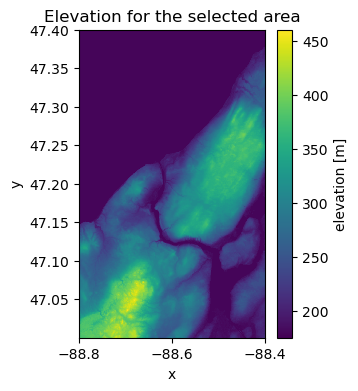

In [25]:
area_of_interest["elevation"].plot(figsize=(3,4))
plt.title("Elevation for the selected area")


Nice! Now we have selected the data for a given area of interest that we specified using the coordinates. In a similar manner, you can select data for any specific area of interest. Couple of important things to remember when selecting data based on coordinates: 
- The coordinate values provided for the selection need to be within the extent of a given input raster dataset. 
- The coordinates provided for the selection need to be in the same coordinate reference system (CRS) as the input raster. For example, here we provided the coordinates as Decimal Degrees because our input data contains coordinates as latitudes and longitudes. However, if your coordinates are represented e.g. in a metric coordinate reference system (e.g. UTM), then your selection should be based on coordinates in a metric system. 

#### Quiz

The lecture showed two ways to select data: `data.isel(x=0, y=0)` and `data.sel(x=-88.8, y=47.4)`. What is the fundamental difference? If you wanted to select the pixel at row 500, column 300, which would you use? What about selecting all data west of longitude -88.5°?

In [ ]:
# Use this cell to enter your solution.


### Selecting data based on logical conditions

A third way to select data from a given raster is based on a specific criteria. To select data based on specific conditions, we can use the `.where()` method which is a handy tool to make conditional selections. For instance, we might be interested to select only such pixels from the raster where the elevation is above 350 meters:

In [26]:
high_altitudes = data.where(data["elevation"] > 350)

Text(0.5, 1.0, 'High altitude areas')

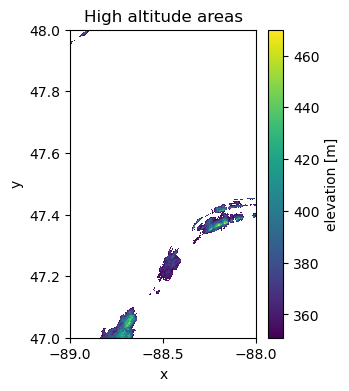

In [27]:
high_altitudes["elevation"].plot(figsize=(3,4))
plt.title("High altitude areas")

As a result, we now have a map that highlights the areas where the elevation is above 350 m. In a similar manner, we can also combine multiple conditions to a single selection. In the following, we will select all pixels where the elevation is above 300 meters and below or equal to 350 meters:

In [28]:
condition = (data["elevation"] > 300) & (data["elevation"] <= 350)
moderate_altitudes = data.where(condition)

Text(0.5, 1.0, 'Moderate altitude areas')

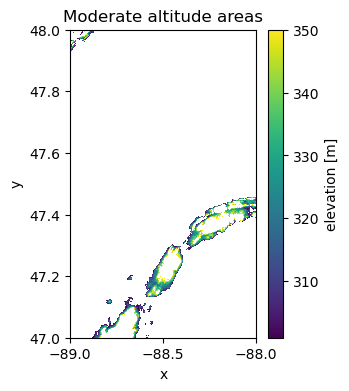

In [29]:
moderate_altitudes["elevation"].plot(figsize=(3,4))
plt.title("Moderate altitude areas")

Now we have a map that highlights the elevations between specific elevation range. In a similar manner, you can conduct selections by combining selection criteria over a single data variable or even combine conditions over multiple different variables. 

## Clipping raster

In the previous section we learned how to select data based on given criteria or by specifying an area of interest. But sometimes, you want to use another dataset to crop or select the data. **Clipping** is one of the common operations in which you clip a given raster Dataset by another layer. This process allows you to crop the data in a way that only the cells that are e.g. within a given Polygon are selected for further analysis. In the following, we will learn how to do this by using the `.rio.clip()` method that comes with the `rioxarray` library.

To be able to clip this xarray.Dataset, we will use the county boundary map for the Upper Peninsula of Michigan by reading from file `upper_peninsula_county.gpkg`. Let's take a look at the data first:

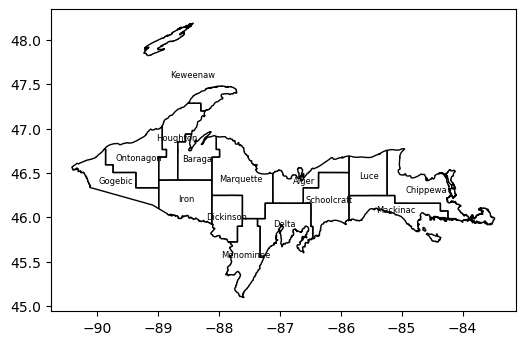

In [30]:
import geopandas as gpd

upper_peninsula = gpd.read_file('data/upper_peninsula_county.gpkg')
#print(upper_peninsula)

# Reproject the data onto the elevation data
upper_peninsula = upper_peninsula.to_crs(data.rio.crs)

ax = upper_peninsula.plot(color='none', edgecolor='black',figsize=(6,6))

for idx, row in upper_peninsula.iterrows():
    # Compute the centroid of the polygon
    centroid = row.geometry.centroid
    # Place the text label at the centroid
    ax.text(centroid.x, centroid.y, row['NAME'], fontsize=6, ha='center', va='center')
    
plt.show()

Now we will clip the elevation data for Houghton county. To do this, we will first create a clip layer:

<Axes: >

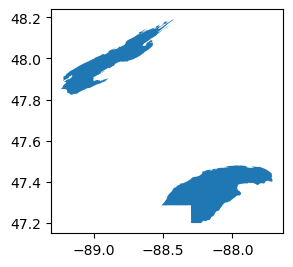

In [31]:
clipping_gdf = upper_peninsula[upper_peninsula.NAME=='Keweenaw']
clipping_gdf.plot(figsize=(3,3))

Then we use the `.rio.clip()` method which takes as input the `geometries` from the clip layer. We can pass the `gpd.GeoSeries` as an input and specify the `crs` to be the same as the input raster data. It is important that the CRS of both layers are the same whenever doing GIS operations between multiple layers. Thus, we use a simple `assert` to check the match before doing the clipping:

In [32]:
# Check that the CRS matches between layers (only continues if True)
assert clipping_gdf.crs == data.elevation.rio.crs

In [33]:
# Clip the raster
data_clipped = data.rio.clip(geometries=clipping_gdf.geometry, crs=data.elevation.rio.crs)
data_clipped

<xarray.Dataset> Size: 83MB
Dimensions:          (x: 3601, y: 2882)
Coordinates:
  * x                (x) float64 29kB -89.0 -89.0 -89.0 ... -88.0 -88.0 -88.0
  * y                (y) float64 23kB 48.0 48.0 48.0 48.0 ... 47.2 47.2 47.2
    spatial_ref      int64 8B 0
Data variables:
    elevation        (y, x) float32 42MB nan nan nan nan nan ... nan nan nan nan
    relative_height  (y, x) float32 42MB nan nan nan nan nan ... nan nan nan nan

Perfect! Now we have successfully clipped the raster with our bounding box. Let's make a map out of our results to see how our data looks like:

Text(0.5, 1.0, 'Elevations of Keweenaw county')

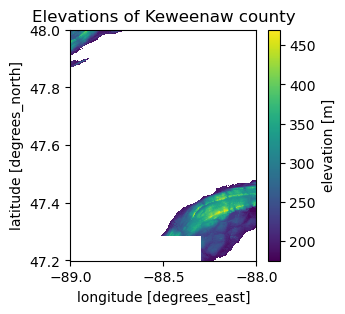

In [34]:
data_clipped["elevation"].plot(figsize=(3, 3))
plt.title("Elevations of Keweenaw county")

Notice that the operations clipped all the variables in our Dataset simultaneously. We can extract basic statistics from elevation and inspect the relative height in this area as follows:

In [35]:
# Maximum elevation
data_clipped["elevation"].max().item()

470.0

In [36]:
# Mean elevation
data_clipped["elevation"].mean().item()

272.32025146484375

In [37]:
# Update the relative height considering the minimum elevation on this area
data_clipped["relative_height"] = data_clipped["elevation"] - data_clipped["elevation"].min()

We can see that the mean elevation in the clipped area is 272 meters while the maximum height is 470 meters. We needed to recalculate the relative height because the baseline minimum elevation in the landscape changed significantly after the clipping operation.

## Masking a raster

Another commonly used approach when working with raster data is to mask the data based on certain criteria or using another geographical layer as a mask. One common reasons for doing this is to exclude water bodies (e.g. lakes or oceans) from the terrain when doing specific analyses. In the following, we will continue working with the same elevation data and mask out Lake Superior from our raster dataset.

First, let's read in the lake polygon dataset, and plot it on top of the elevation data.


<Axes: >

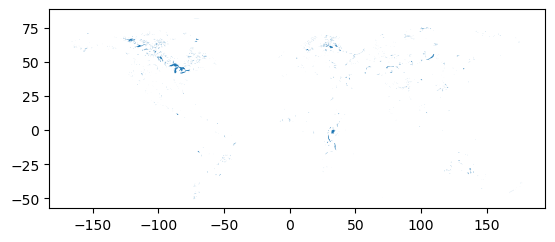

In [38]:
# read the elevation data
data = xr.open_dataset('data/n47_w089_1arc_v3.tif',engine="rasterio")
data = data.rename({"band_data": "elevation"})

# read the global lake data (polygons)
lakes = gpd.read_file('data/global_10m_lakes.zip')
lakes = lakes.to_crs(data.rio.crs)
lakes.plot()

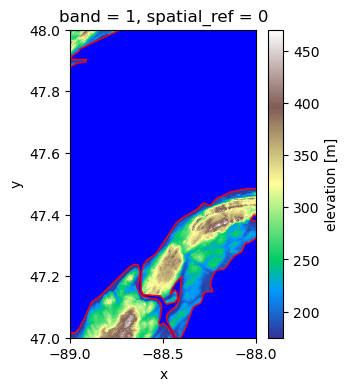

In [39]:
fig, ax = plt.subplots(figsize=(3,4))
data["elevation"].plot(ax=ax, cmap='terrain')#,cbar_kwargs={"shrink": 0.7,"aspect": 20})
lakes.plot(ax=ax,facecolor="blue",edgecolor="red",alpha=1)
ax.set_aspect("auto")

As we can see, Lake Superior covers large portions of the elevation data. We can mask these areas using rioxarray. To do this, we can use the same `.rio.clip()` method as in the previous example. However, we do not want to remove those cells from our Dataset but only mask them out, so that the values on those areas are replaced with NaN values. By using parameters `drop=False` and `invert=True`, the cells that are intersecting with the lake geometries will be masked with NaNs:

Text(0.5, 1.0, 'Elevation data with a mask')

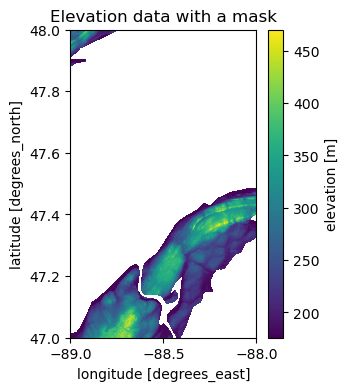

In [40]:
masked_data = data.rio.clip(
    geometries=lakes.geometry,
    drop=False,
    invert=True,
    crs=data.elevation.rio.crs,
)
masked_data["elevation"].plot(figsize=(3,4))
plt.title("Elevation data with a mask")

As a result, we now have a new Dataset where the elevation values overlapping with Lake Superior have been converted to NaNs. We can now compare whether e.g. the mean land surface elevation differs from the original one where the lakes were still included:

In [41]:
print("Mean elevation with lakes:", data["elevation"].mean().round().item())
print("Mean elevation without lakes:", masked_data["elevation"].mean().round().item())

Mean elevation with lakes: 199.0
Mean elevation without lakes: 267.0


Based on this comparison, we can see that masking out the lakes increases the mean elevation in the area.

#### Quiz

Both clipping and masking use `.rio.clip()` with a vector layer. The lecture clipped elevation to Keweenaw County and also masked out Lake Superior. How do the two operations differ in terms of output shape and cell values? What parameter controls the behavior?

In [ ]:
# Use this cell to enter your solution.


Before masking, the mean elevation was one value; after masking, it was higher. Why? What does this tell you about how elevation is recorded over water bodies in a DEM?

In [ ]:
# Use this cell to enter your solution.


## Creating a raster mosaic by merging datasets

One common operation when working with raster data is to combine multiple individual raster layers (also called tiles) into a single larger raster dataset, often called raster mosaic. This can be done with the `.merge_datasets()` function in rioxarray.
Here, we will create a mosaic of two DEM tiles covering the UP Michigan. 

First we will read elevation data from all tiles.

In [42]:
files = [
    'data/n47_w089_1arc_v3.tif',
    'data/n46_w089_1arc_v3.tif'
]
datasets = [
    xr.open_dataset(file, engine="rasterio", masked=True, band_as_variable=True)
    for file in files
]

Now we have stored all the xarray.Dataset layers inside the list `datasets`. We can investigate the contents of the first Dataset in our list as follows:

In [43]:
datasets[0]

<xarray.Dataset> Size: 52MB
Dimensions:      (x: 3601, y: 3601)
Coordinates:
  * x            (x) float64 29kB -89.0 -89.0 -89.0 -89.0 ... -88.0 -88.0 -88.0
  * y            (y) float64 29kB 48.0 48.0 48.0 48.0 ... 47.0 47.0 47.0 47.0
    spatial_ref  int64 8B ...
Data variables:
    band_1       (y, x) float32 52MB ...
Attributes: (12/23)
    AREA_OR_POINT:                Point
    DTED_CompilationDate:         2
    DTED_DataEdition:             1
    DTED_DigitizingSystem:        SRTM      
    DTED_HorizontalAccuracy:      13
    DTED_HorizontalDatum:         WGS84
    ...                           ...
    DTED_SecurityCode_UHL:        U  
    DTED_UniqueRef_DSI:           F18 117        
    DTED_UniqueRef_UHL:           F18 117     
    DTED_VerticalAccuracy_ACC:    4
    DTED_VerticalAccuracy_UHL:    4
    DTED_VerticalDatum:           E96

As we can see an individual Dataset has a shape with 3601 cells on each dimension (x and y) and the name of the data variable `band_1` which represents the elevation values. Let's visualize these raster tiles in separate maps to see how they look like. To do this, we use `plt.subplots()` to initialize a figure with 1x2 subplots and then visualize the rasters one by one. We use `vmax` parameter to specify a same value scale for each layer that makes the colors in the map comparable:

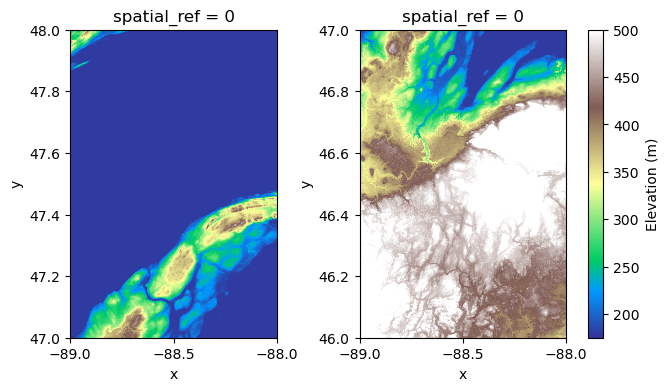

In [44]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(7, 4), gridspec_kw={'wspace': 0.4})

# Plot both without colorbars
im0 = datasets[0]["band_1"].plot(ax=axes[0], cmap='terrain', vmax=500, add_colorbar=False)
im1 = datasets[1]["band_1"].plot(ax=axes[1], cmap='terrain', vmax=500, add_colorbar=False)

# Create one shared colorbar
cbar = fig.colorbar(im1, ax=axes, orientation='vertical', fraction=0.046, pad=0.04)
cbar.set_label("Elevation (m)")

plt.show()

From the figure we can see that these tiles seem to belong together naturally as the elevation values and coordinates along the y-axis continue smoothly. Hence, we can stitch them together into a single larger raster Dataset.

To merge multiple xarray.Datasets together, we can use the `.merge_datasets()` function from `rioxarray`:

In [45]:
from rioxarray.merge import merge_datasets

mosaic = merge_datasets(datasets)
mosaic

<xarray.Dataset> Size: 104MB
Dimensions:      (x: 3601, y: 7201)
Coordinates:
  * x            (x) float64 29kB -89.0 -89.0 -89.0 -89.0 ... -88.0 -88.0 -88.0
  * y            (y) float64 58kB 48.0 48.0 48.0 48.0 ... 46.0 46.0 46.0 46.0
    spatial_ref  int64 8B 0
Data variables:
    band_1       (y, x) float32 104MB 179.0 179.0 179.0 ... 381.0 381.0 380.0
Attributes: (12/23)
    AREA_OR_POINT:                Point
    DTED_CompilationDate:         2
    DTED_DataEdition:             1
    DTED_DigitizingSystem:        SRTM      
    DTED_HorizontalAccuracy:      13
    DTED_HorizontalDatum:         WGS84
    ...                           ...
    DTED_SecurityCode_UHL:        U  
    DTED_UniqueRef_DSI:           F18 117        
    DTED_UniqueRef_UHL:           F18 117     
    DTED_VerticalAccuracy_ACC:    4
    DTED_VerticalAccuracy_UHL:    4
    DTED_VerticalDatum:           E96

Now we have successfully merged the individual datasets together, which is evident from the shape of the new Dataset (3601 cells on x and 7201 cells on y axis). Let's rename our data variable and plot the result to see how it looks like:

In [46]:
mosaic = mosaic.rename({"band_1": "elevation"})

# Save the merged raster
#mosaic.rio.to_raster('data/merged_n46_w089-n47_w089_1arc_v3.tif')

Text(0.5, 1.0, 'Elevation in UP Michigan')

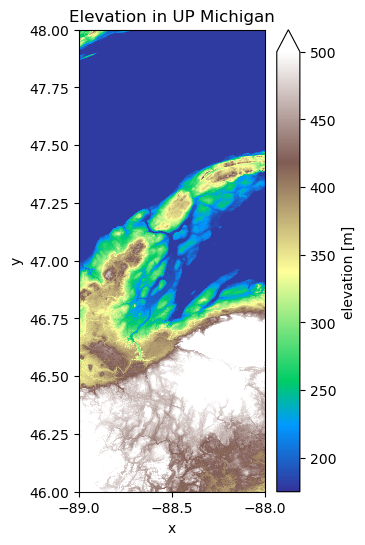

In [47]:
mosaic["elevation"].plot(figsize=(3,6), cmap='terrain', vmax=500)
plt.title("Elevation in UP Michigan")

## Raster to vector conversion (vectorize)

Another commonly used technique when working with geographic data is to convert the data from raster to vector format and vice versa. These conversion techniques are commonly called as `vectorize` or `rasterize` operations.

When we convert a raster to vector, raster cells are converted into shapely.Polygon objects and the values of the cells are stored as an attribute (column) in the resulting GeoDataFrame. To convert xarray.DataArray into vector, you can use the `geocube` library. In the following, we continue working with the elevation data we clipped earlier.

If `geocube` is not installed in your pythongis environment, you can install it as follows:

(make sure the pythongis environment is activated first)

`conda install geocube`

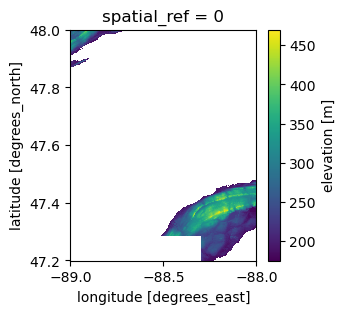

In [48]:
data_clipped["elevation"].plot(figsize=(3,3))

To vectorize a given variable in the Dataset, you can use the `vectorize` function from the `geocube` library as follows:

In [49]:
from geocube.vector import vectorize

gdf = vectorize(data_clipped["elevation"].astype("float32"))

# Use the same projection as data_clipped
gdf = gdf.to_crs(data_clipped.rio.crs)

gdf.shape

(502294, 2)

In [50]:
gdf.head()

,elevation,geometry
0,192.0,"POLYGON ((-88.99681 48.00014, -88.99681 47.999..."
1,198.0,"POLYGON ((-88.99653 48.00014, -88.99653 47.999..."
2,206.0,"POLYGON ((-88.99625 48.00014, -88.99625 47.999..."
3,216.0,"POLYGON ((-88.99597 48.00014, -88.99597 47.999..."
4,226.0,"POLYGON ((-88.99569 48.00014, -88.99569 47.999..."


Now we have converted the DataArray into vector format and got a GeoDataFrame containing the geometries of individual cells as shapely.Polygon objects in the **geometry** column, and the cell values in the **elevation** column. The name of the column will be automatically added based on the name of the DataArray. As we can see from `gdf.shape`, all the raster cells were added as individual rows into the GeoDataFrame.

When working with surface data (e.g. elevation), it is common to have similar values close to each other in the raster cells and often there are specific regions where the elevation does not change. Therefore, after vectorization operation, it is a good idea to dissolve the geometries based on the data attribute and merges geometries with identical values into single geometries. To do this, we can use the `.dissolve()` function:


In [51]:
gdf = gdf.dissolve(by="elevation", as_index=False)
gdf.shape

(296, 2)

As we can see, the number of rows in our GeoDataFrame was reduced dramatically. Let's finally plot our GeoDataFrame to see how the data looks like:

<Axes: >

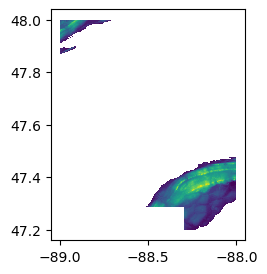

In [52]:
gdf.plot(column="elevation",figsize=(3,3))

As we can see from the figure, the map looks identical to the original DataArray which means that the conversion works as it should. 

It is important to keep in mind that the raster data structure (i.e. arrays) is much more efficient to process continuous surfaces. When every cell in the 2D array is converted into polygon geometries, the processing and visualization of the data typically becomes more resource intensive. There are approaches to deal with this issue e.g. by categorizing the data values of the surface into specific elevation classes (e.g. with 5 meter intervals) and then dissolving the geometries into larger Polygon shapes. 

Another technique to consider is downscaling your data into lower resolution, meaning that the size of an individual cell will be larger. Naturally, both of these techniques has an impact on the data quality as the data is generalized and aggregated. It is a good idea to do the preprocessing for the raster data before vectorizing it, especially if you have large raster arrays because array operations in xarray are very efficient.

## Vector to raster conversion (rasterize)

Let's continue and see how to do the conversion from vector to raster data format, i.e. how to rasterize a vector dataset. In this example, we will rasterize the Great Lake basins. Let's have a look how the data looks like:

In [53]:
import geopandas as gpd
lakebasins = gpd.read_file('data/greatlakes_subbasins.zip')
lakebasins

,merge,geometry
0,lk_erie,"POLYGON ((-80.27591 44.09303, -80.26687 44.085..."
1,lk_huron,"POLYGON ((-79.85601 47.28073, -79.85985 47.239..."
2,lk_mich,"POLYGON ((-86.11485 46.54744, -86.11092 46.546..."
3,lk_ont,"POLYGON ((-78.40375 45.35472, -78.40661 45.341..."
4,lk_sup,"POLYGON ((-88.52978 50.74652, -88.50701 50.692..."


In [54]:
lakebasins.crs

<Geographic 2D CRS: GEOGCS["Geographic",DATUM["North_American_Datum_19 ...>
Name: Geographic
Axis Info [ellipsoidal]:
- lon[east]: Longitude (Degree)
- lat[north]: Latitude (Degree)
Area of Use:
- undefined
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: <custom>

The GeoDataFrame does not include any useful numerical data to store as an attribute into the raster DataArray. Thus, let's create one numerical attribute and calculate the area of the lakes.

In [55]:
# Reproject to metric system
lakebasins_utm = lakebasins.to_crs(epsg=3175)

# Calculate the area in km2
lakebasins_utm["area_km2"] = lakebasins_utm.area / 1000000

# Join the area information with the original gdf
lakebasins = lakebasins.join(lakebasins_utm[["area_km2"]])

lakebasins.head(5)

,merge,geometry,area_km2
0,lk_erie,"POLYGON ((-80.27591 44.09303, -80.26687 44.085...",105543.791659
1,lk_huron,"POLYGON ((-79.85601 47.28073, -79.85985 47.239...",193118.762092
2,lk_mich,"POLYGON ((-86.11485 46.54744, -86.11092 46.546...",174258.414990
3,lk_ont,"POLYGON ((-78.40375 45.35472, -78.40661 45.341...",81099.854792
4,lk_sup,"POLYGON ((-88.52978 50.74652, -88.50701 50.692...",209283.530233


In the previous step, we first reprojected the data into EPSG:3175 (NAD83 / Great Lakes and St. Lawrence Albers) which is a projected CRS for the Great Lakes region. Then we calculated the area of the lakes into square kilometers, and finally joined the area into our original GeoDataFrame that is in WGS84 CRS.

Now we are ready to rasterize our GeoDataFrame into xarray. To do this, we can use the `make_geocube()` function from the `geocube` library:

In [56]:
from geocube.api.core import make_geocube

lakebasins_ds = make_geocube(
    vector_data=lakebasins,
    measurements=[ "area_km2"],
    resolution=(-0.01, 0.01),
    output_crs="epsg:4326",
)
lakebasins_ds

<xarray.Dataset> Size: 16MB
Dimensions:      (y: 1037, x: 1871)
Coordinates:
  * y            (y) float64 8kB 50.77 50.77 50.75 50.74 ... 40.44 40.42 40.41
  * x            (x) float64 15kB -93.23 -93.22 -93.21 ... -74.55 -74.54 -74.53
    spatial_ref  int64 8B 0
Data variables:
    area_km2     (y, x) float64 16MB nan nan nan nan nan ... nan nan nan nan nan

As a result, we now have an xarray.Dataset with one data variable. In the above step, we specified that the `lakes` GeoDataFrame is used as input `vector_data` and the columns `area_km2` is included as `measurements`, i.e. the data that are stored into separate xarray variables. The `resolution` parameter defines the spatial resolution of the output grid, i.e. size of a single pixel in the raster. In our case, we specified a tuple with values `(-0.01, 0.01)` in decimal degrees because the CRS of our input is WGS84. Thus, resolution `0.01` indicates that the size of a single pixel in our raster is approximately 1x1 kilometers (1.11km). The negative sign for y-resolution is used because raster transformations often use negative values for the y-axis in many CRS systems, where the y-coordinates decrease as you move down the raster. Finally, the `output_crs` defines the CRS for the resulting Dataset. 

Let's make a map out of our data to see how the result looks like:

Text(0.5, 1.0, 'Rasterized Great Lakes basins')

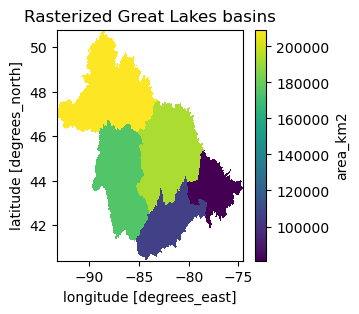

In [57]:
lakebasins_ds["area_km2"].plot(figsize=(3,3))
plt.title("Rasterized Great Lakes basins")

As a result, we have now rasterized the lake basins containing the area_km2 values. 

## Resampling raster data

In the following section, we will introduce a technique that allows you to resample raster data. **Resampling** refers to changing the cell values due to changes in the raster grid and the effective cell size of a dataset. There are two ways to resample your raster data. 

- **Upscaling (or upsampling)** refers to cases of converting raster to higher resolution, i.e. smaller cells. 
- **Downscaling (or downsampling)** refers to cases of converting to lower resolution, i.e. having larger cell sizes. 

In the following, we will see how we can resample an xarray.Dataset by downscaling and upscaling the data. 

We can resample xarray data using the rioxarray library. Whenever downscaling data, you are ultimately aggregating the information because multiple individual cells are merged into one larger cell to be stored in the output grid. Thus, it is important to decide the `resampling` method which determines how the data values are aggregated.

In our case, taking the **average** makes sense since the input data represents elevation. However, in some cases you might be interested to **sum** all the cell values if your input data would represent population counts in a given region. There are also other ways to resample the data, such as extracting the minimum (**min**), maximum (**max**), median (**med**) or the **mode** (i.e., most frequent value) from the input cells.

### Downscaling

In the following, we will downscale the elevation data using a downscale factor of 50. This means that the output raster will be 50 times smaller in terms of its dimensions compared to the input raster. To downscale the data, you need to define the new shape for our target raster Dataset.

Here, we use a specific `downscale_factor` to calculate the new width and height for the output Dataset. The width and height for the target Dataset need to be provided as integer values. Thus we ensure that the dimensions are integers by rounding (**round()**) and converting the number with **int()**. The `.rio.reproject()` method is then used to downscale the data using the new shape. The `resampling` parameter defines the resampling method, in this case, **Resampling.average**. The **Resampling** class from rasterio library provides the methods for resampling:

In [58]:
from rasterio.enums import Resampling

# Define the new shape
downscale_factor = 50
new_width = int(round(data.rio.width / downscale_factor))
new_height = int(round(data.rio.height / downscale_factor))

# Downscale the data
data_downscaled = data.rio.reproject(
    dst_crs=data.rio.crs,
    shape=(new_height, new_width),
    resampling=Resampling.average,
)

data_downscaled

<xarray.Dataset> Size: 22kB
Dimensions:      (x: 72, y: 72, band: 1)
Coordinates:
  * x            (x) float64 576B -88.99 -88.98 -88.97 ... -88.03 -88.02 -88.01
  * y            (y) float64 576B 47.99 47.98 47.97 47.95 ... 47.03 47.02 47.01
  * band         (band) int64 8B 1
    spatial_ref  int64 8B 0
Data variables:
    elevation    (band, y, x) float32 21kB 261.3 280.6 270.4 ... 179.0 179.0

As we can see, the dimensions of the new downscaled Dataset is 72x72 cells on x and y axis, which is 50 times smaller compared to the original data (3601x3601):

In [59]:
print("Original resolution:", data.rio.resolution())
print("Downscaled resolution:", data_downscaled.rio.resolution())

Original resolution: (0.0002777777777777778, -0.0002777777777777778)
Downscaled resolution: (0.013892746913580207, -0.013892746913580207)


By comparing the spatial resolution between the datasets, we can see that the new resolution of the downscaled Dataset is slightly over 1x1 km (~0.014 decimal degrees). Let's visualize the downscaled Dataset next to the original Dataset, see how they compare with each other:

Text(0.5, 1.0, 'Downscaled elevation')

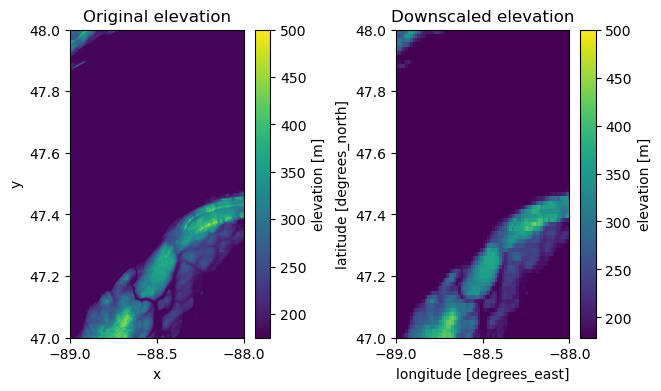

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(7,4), gridspec_kw={'wspace': 0.5})

# Plot the tiles to see how they look separately
data["elevation"].plot(ax=axes[0], vmax=500, add_colorbar=True)
data_downscaled["elevation"].plot(ax=axes[1], vmax=500, add_colorbar=True)
axes[0].set_title("Original elevation")
axes[1].set_title("Downscaled elevation")

The downscaling operation seem to have worked well as the patterns are still similar compared to the input data, although the spatial resolution is much lower. The data is downscaled so much that it is actually possible to identify individual pixels of the grid. 

### Upscaling

The process of upscaling works similarly to downscaling - we can use the same rioxarray method to increase the resolution of the input raster. In the following, we will specify that the new shape of the output Dataset will be two times larger than the input data. When upscaling, you are ultimately estimating values to new pixel cells based on the neighboring raster values of a given cell in the input raster.

There are various ways to interpolate data:

| Resampling Method    | Description                                                                                                               |
|:--------------------:|:-------------------------------------------------------------------------------------------------------------------------:|
| `nearest`            | Selects the value of the closest pixel without interpolation. Fast but can produce blocky artifacts.                      |
| `bilinear`           | Performs linear interpolation using the four nearest pixels, creating a smoother result than nearest-neighbor.            |
| `cubic`              | Uses bicubic interpolation, considering 16 surrounding pixels. Smoother output than bilinear. Higher computational cost.  |
| `cubic_spline`       | Applies cubic spline interpolation for even smoother results, but requires more processing power.                         |
| `lanczos`            | Uses a sinc-based interpolation over a larger pixel neighborhood, producing resampling with significant smoothing.        |
| `average`            | Average resampling, computes the weighted average of all non-NODATA contributing pixels.                                  |


In the following, we will take advantage of a `Resampling.bilinear` resampling method which determines the value of a new pixel by taking a weighted average of the four nearest input pixels:

In [61]:
from rasterio.enums import Resampling

# Define the new shape
upscale_factor = 2
new_width = data.rio.width * upscale_factor
new_height = data.rio.height * upscale_factor

# Upscale the data
data_upscaled = data.rio.reproject(
    data.rio.crs,
    shape=(new_height, new_width),
    resampling=Resampling.bilinear,
)

Now we have successfully upscaled our data. We can confirm by comparing the shapes of the original and upscaled datasets:

In [62]:
print("Shape - Original:", data.rio.shape)
print("Shape - Upscaled:", data_upscaled.rio.shape)

Shape - Original: (3601, 3601)
Shape - Upscaled: (7202, 7202)


As expected, the new `data_upscaled` raster contains twice as many pixels compared to the input. In a similar manner, you can upscale the data into different resolutions by providing a given target `shape` to your new raster layer. Notice that there is no "correct” way to do upscaling as all resampling methods involve interpolation that introduces uncertainty to the results. Let's finally confirm that our upscaled data looks correct also on a map:


#### Quiz
Downscaling vs. Upscaling — Does resampling create or destroy information?

The lecture downscaled by a factor of 50 (3601→72 pixels) and upscaled by a factor of 2 (3601→7202 pixels). Does downscaling lose information? Does upscaling create new information? Why does the choice of resampling method (e.g., nearest, bilinear) matter?

In [ ]:
# Use this cell to enter your solution.



## Summary

In this module, we learned the essential operations for working with raster data in Python:

1. **Data structures**: `xr.Dataset` (collection of variables) and `xr.DataArray` (single variable with coordinates)
2. **Reading data**: `xr.open_dataset()` with the rasterio engine
3. **Selection**: `.isel()` (by index), `.sel()` (by coordinate), `.where()` (by condition)
4. **Spatial operations**: `.rio.clip()` (clip to boundary), masking with `invert=True`
5. **Merging**: `merge_datasets()` to create mosaics from multiple tiles
6. **Format conversion**: `vectorize()` (raster to vector) and `make_geocube()` (vector to raster)
7. **Resampling**: `.rio.reproject()` with different resolutions for upscaling/downscaling

**Key terms:**
| Term | Definition |
|------|-----------|
| **Raster** | A grid of cells (pixels) where each cell stores a value |
| **Resolution** | The size of each pixel (e.g., 30m means each pixel covers 30x30 meters) |
| **Band** | A single layer of values in a raster (e.g., elevation, or a single color channel) |
| **Mosaic** | A single raster created by merging multiple adjacent tiles |
| **Vectorize** | Convert raster cells into vector polygons |
| **Rasterize** | Convert vector features into raster cells |
| **Resampling** | Changing the pixel size (resolution) of a raster |

Text(0.5, 1.0, 'Upscaled elevation')

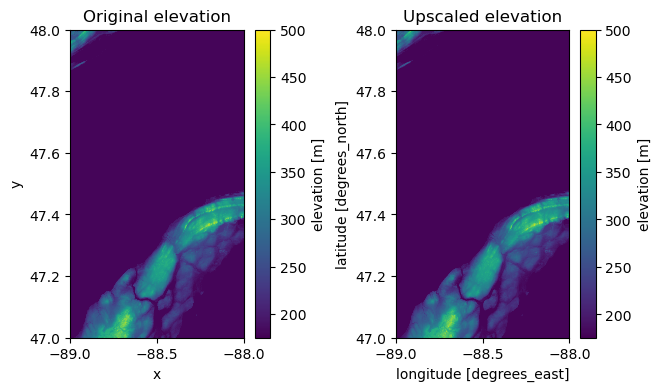

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(7,4), gridspec_kw={'wspace': 0.5})

# Plot the tiles to see how they look separately
data["elevation"].plot(ax=axes[0], vmax=500, add_colorbar=True)
data_upscaled["elevation"].plot(ax=axes[1], vmax=500, add_colorbar=True)
axes[0].set_title("Original elevation")
axes[1].set_title("Upscaled elevation")